# FIP 03 — DA and NE-proxy: shared and unique encoding of movement

DA and the PL-GCaMP "NE" proxy are recorded together in every session of `DA_NE_4channels`.
`fip_02_ne_only_events.ipynb` found their transients coincide far above a circular-shift null
(0.298 observed vs. 0.151 null, p = 0.001). This notebook starts from that coincidence and
partitions the motion-energy variance the two signals explain into three parts: DA-unique,
NE-unique, and shared.

The notebook runs in one direction: load and align (§2), characterize the DA↔NE relationship
(§3–§4), fit a lagged encoding model against motion energy (§5), decompose its variance (§6).

**"NE"**: this dataset's curation carries no norepinephrine (nLight) sensor; per-project
convention the PL-GCaMP channel stands in for NE, following `fip_02_ne_only_events.ipynb`.
**"DA"**: NAc dLight. Every result below inherits that proxy.

**Scale**: motion energy exists for 10 sessions, all from subject 808054 (2025-09-02 →
2025-09-15), out of 172 curated FIP sessions. The sampling unit for every test is the session,
and the 10 sessions come from one animal, so §6's intervals describe that animal.

**Upstream preprocessing**: isosbestic/background correction and dF/F are already applied in the
`*_dff-poly` event variants of the parquet asset (`6babbf3d-6970-4456-aab5-d730ed57c269`,
saved by `rachel_analysis_utils.nwb_utils.save_nwb_list`). This notebook adds `zscore_fip` and a
common 20 Hz grid.

**Two run-level switches**, both set in §1: `TARGET` selects a continuous or event-count
behavioral target, `ME_TRANSFORM` selects the continuous target's scaling. Each is resolved in
exactly one place and flows through to every axis label and saved filename.

Runtime after `load_curated_sessions()`: roughly 15 minutes.

## Imports & setup

`fip_utils` supplies loading, curation, session selection, motion energy on the FIP clock, and
the signal helpers (`zscore` / `threshold_onsets` / `peri_event` / `norm_xcorr` / `window_mean`)
shared by `fip_00`–`fip_02`. `plotstyle` supplies this repo's figure standards, which the rest of
the `fip_*` series does not use — §7 notes the divergence. `sklearn` provides the two regressors;
it is installed on the capsule transitively rather than declared in the Dockerfile.

In [3]:
import os
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal

# Shared fip_* setup: loading, curation, session select, example channels, motion energy on
# the FIP clock, and the signal helpers (zscore / threshold_onsets / peri_event / norm_xcorr).
# autoreload so editing fip_utils.py doesn't cost a kernel restart + a full session reload.
%load_ext autoreload
%autoreload 2
import fip_utils as fu

# zscore_fip -- the same z-scoring Rachel's pipeline uses. This notebook needs only that one
# normalization, not fip_01's per-trial baseline/tonic pipeline, because the model below works
# on continuous time rather than per-trial windows.
from aind_dynamic_foraging_data_utils import enrich_dfs

# Repo figure standards. The rest of the fip_* series uses bare matplotlib; see section 7.
from plotstyle import apply_style, PALETTE, style_ax, save_fig

# Ridge for the continuous target, Poisson for the event-count target. Imported by name rather
# than RidgeCV: RidgeCV's store_cv_values kwarg (used in eph_05) is gone in sklearn >= 1.7.
from sklearn.linear_model import Ridge, PoissonRegressor

%matplotlib inline
apply_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
# ── Run-level switches ────────────────────────────────────────────────────────
TARGET = "continuous"     # "continuous" (ridge on motion energy) | "events" (Poisson on ME onsets)
ME_TRANSFORM = "log1p"    # "log1p" | "raw" -- continuous target only, ignored when TARGET="events"

# ── Fixed parameters ──────────────────────────────────────────────────────────
FS = 20                   # Hz, common grid for every signal in this notebook
LAG_WINDOW = (-2.0, 5.0)  # s, encoding-model lag span; positive lag = FIP leads behavior
N_BASIS = 8               # raised-cosine bumps spanning LAG_WINDOW
MAXLAG = 3.0              # s, cross-correlation range
N_SHIFT = 200             # circular shifts / label shuffles; p-value floor 1/(N_SHIFT+1)
N_PERM = 50               # circular-shift permutations of the encoding model
N_BOOT = 10000            # bootstrap resamples over sessions
N_BLOCKS = 5              # contiguous cross-validation blocks
EMBARGO_S = 7.0           # s excluded either side of each test block (= full lag span)
ALPHAS = np.logspace(-1, 4, 6)
ONSET_KW = {"z_thresh": 2.5, "refractory": 0.5, "min_run": 3}  # fip_00's movement-onset setting
SEED = 0

# ── Output ────────────────────────────────────────────────────────────────────
FIG_DIR = "/root/capsule/scratch/figures/fip"  # note: /scratch is not kept by a reproducible run
SAVE_FIG = True

DA_COLOR, NE_COLOR, SHARED_COLOR = PALETTE["pos"], PALETTE["neg"], PALETTE["accent"]
rng = np.random.default_rng(SEED)

SCORE_LABEL = "cross-validated R$^2$" if TARGET == "continuous" else "cross-validated D$^2$"
RUN_TAG = TARGET + "_" + (ME_TRANSFORM if TARGET == "continuous" else "onsets")
print("TARGET = %s | ME_TRANSFORM = %s | score = %s | tag = %s"
      % (TARGET, ME_TRANSFORM, SCORE_LABEL, RUN_TAG))

TARGET = continuous | ME_TRANSFORM = log1p | score = cross-validated R$^2$ | tag = continuous_log1p


## 2. Load, align, and check bandwidth

One normalization runs throughout: motion energy is attached to `df_fip` raw, then `zscore_fip`
z-scores it identically to a real FIP channel, and everything downstream reads `data_z`. The
three signals arrive on slightly different clocks, so all of them are interpolated onto one
`FS`-Hz grid covering their common span.

The loop skips a session when `locate_me_assets` finds no motion energy (162 of 172 sessions)
and when `pick_example` finds no dLight or GCaMP channel.

In [39]:
# Loading the NWB list costs tens of GB and several minutes. Nothing past section 2 needs it:
# the cache keeps only the ingredients each later section reads -- the two FIP traces, the raw
# motion-energy trace, the time grid, the event times and the labels. A few tens of MB.
#
# `me` and `y` are NOT cached. They are derived from `me_raw` in the cell below, on both the
# cached and the rebuild path, so TARGET and ME_TRANSFORM can be changed freely without ever
# rebuilding. One file serves every combination.
#
# Set REBUILD = True after changing FS or ONSET_KW, which do affect the cached ingredients,
# and for the channel-diagnostic work that walks nwb_list directly.
CACHE = "/root/capsule/scratch/fip_03_sessions.pkl"
REBUILD = False

USE_CACHE = not REBUILD and os.path.exists(CACHE)
if USE_CACHE:
    print("cache written %s -- set REBUILD = True to reload from the NWB list"
          % time.ctime(os.path.getmtime(CACHE)))
else:
    nwb_list = fu.load_curated_sessions()

cache written Wed Sep 23 19:20:26 2026 -- set REBUILD = True to reload from the NWB list


In [40]:
if USE_CACHE:
    sessions = pickle.load(open(CACHE, "rb"))
    print("loaded %d sessions from cache" % len(sessions))
else:
    sessions = []
    skipped = {"no_me": 0, "no_channel": 0, "other": 0}

    for nwb in nwb_list:
        try:
            s = fu.process_session(nwb, onset_kw=ONSET_KW)
        except FileNotFoundError:
            skipped["no_me"] += 1
            continue
        except ValueError:
            skipped["other"] += 1
            continue

        # ME goes in raw and is z-scored by the same call that z-scores the FIP channels.
        df_fip = fu.attach_me_to_df_fip(s["df_fip"], s["t_me"], s["me"], s["session_id"])
        df_fip_z = enrich_dfs.zscore_fip(df_fip)
        meta = fu.build_meta(df_fip_z)

        try:
            da_info = fu.pick_example(meta, df_fip_z, "dLight")
            ne_info = fu.pick_example(meta, df_fip_z, "Gcamp")
        except ValueError:
            skipped["no_channel"] += 1
            continue

        t_da, da = fu.get_trace(df_fip_z, da_info["event"], data_col="data_z")
        t_ne, ne = fu.get_trace(df_fip_z, ne_info["event"], data_col="data_z")
        t_me, me_raw = fu.get_trace(df_fip_z, "ME", data_col="data")

        # Common grid over the span all three signals cover.
        lo = max(t_da.min(), t_ne.min(), t_me.min())
        hi = min(t_da.max(), t_ne.max(), t_me.max())
        grid = np.arange(lo, hi, 1.0 / FS)
        da_i = np.interp(grid, t_da, da)
        ne_i = np.interp(grid, t_ne, ne)
        me_i = np.interp(grid, t_me, me_raw)

        # Onsets trimmed to the grid; the target itself is derived below, not stored.
        onsets = s["me_onsets"]
        onsets = onsets[(onsets >= grid[0]) & (onsets <= grid[-1])]

        sessions.append({
            "session_id": s["session_id"], "subject_id": s["subject_id"],
            "t": grid, "da": da_i, "ne": ne_i, "me_raw": me_i,
            "me_onsets": onsets, "go_cues": s["go_cues"],
            "da_region": da_info["region"], "ne_region": ne_info["region"],
        })

    os.makedirs(os.path.dirname(CACHE), exist_ok=True)
    pickle.dump(sessions, open(CACHE, "wb"), protocol=4)
    print("cached %d sessions -> %s" % (len(sessions), CACHE))
    print("skipped: %s" % skipped)

# Derived from the cached ingredients every run, so the two run-level switches cost nothing
# to change. log1p compresses motion energy's right tail so the fit is not dominated by a
# handful of large-movement frames; log1p(0) = 0 handles the exact zeros, including the leading
# pad fip_utils adds for the N-1 frame count.
for s in sessions:
    s["me"] = fu.zscore(s["me_raw"])
    if TARGET == "continuous":
        me_t = np.log1p(np.clip(s["me_raw"], 0.0, None)) if ME_TRANSFORM == "log1p" else s["me_raw"]
        s["y"] = fu.zscore(me_t)
    else:
        edges = np.append(s["t"], s["t"][-1] + 1.0 / FS)
        s["y"] = np.histogram(s["me_onsets"], bins=edges)[0].astype(float)

subjects = sorted({s["subject_id"] for s in sessions})
print("%d sessions usable | %d subjects: %s" % (len(sessions), len(subjects), subjects))
print("target = %s | %s" % (RUN_TAG, SCORE_LABEL.replace("$", "")))
print("median session length: %.1f min | mean ME onsets/session: %.0f"
      % (np.median([len(s["t"]) for s in sessions]) / FS / 60,
         np.mean([len(s["me_onsets"]) for s in sessions])))

loaded 10 sessions from cache
10 sessions usable | 1 subjects: ['808054']
target = continuous_log1p | cross-validated R^2
median session length: 74.9 min | mean ME onsets/session: 1096


### Bandwidth

Two things can make one trace smoother than another. Different filtering or resampling applied to
one and not the other is the fixable kind, and it is already equal here: both channels come out
of the same `df_fip`, the same acquisition, the same timestamps and the same upstream dF/F.
What remains is sensor kinetics — dLight and GCaMP have different rise and decay constants, so
each indicator low-passes its own transmitter at a different cutoff. Resampling does not touch
that, and correcting it would need each sensor's kernel.

Panel (b) measures the difference and leaves the signals alone. Overlapping spectra mean §6's
partition is clean. A lower median frequency for one channel means it carries an advantage at
predicting slow structure in motion energy and a handicap at fast structure, which would appear
in the DA-unique / NE-unique split as though it were biology — §7 carries that forward.

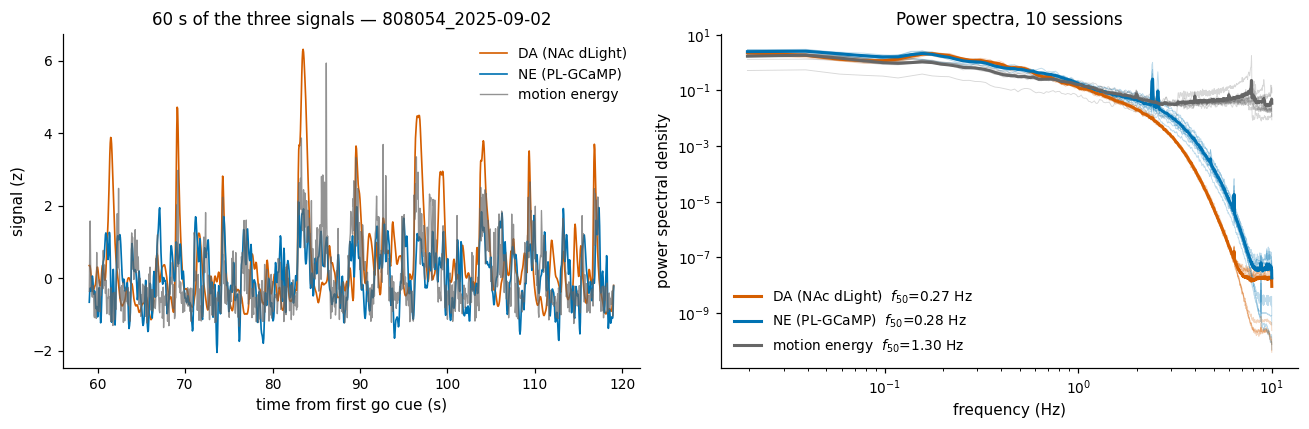

median-power frequency  DA (NAc dLight)    0.270 +/- 0.017 Hz (mean +/- SD over sessions)
median-power frequency  NE (PL-GCaMP)      0.275 +/- 0.038 Hz (mean +/- SD over sessions)
median-power frequency  motion energy      1.299 +/- 1.676 Hz (mean +/- SD over sessions)
Wilcoxon DA vs NE f50: p = 0.7257


In [41]:
def median_freq(x, fs=FS, nperseg=1024):
    """Frequency below which half of a signal's power lies.

    Parameters
    ----------
    x : array_like
        Signal, uniformly sampled.
    fs : float
        Sampling rate in Hz.
    nperseg : int
        Welch segment length.

    Returns
    -------
    tuple
        ``(freqs, psd, f50)`` -- the Welch spectrum and its median-power frequency.
    """
    f, pxx = signal.welch(np.asarray(x, float), fs=fs, nperseg=nperseg)
    csum = np.cumsum(pxx)
    f50 = float(f[np.searchsorted(csum, csum[-1] / 2.0)])
    return f, pxx, f50


ex = sessions[0]
win = (ex["t"] >= ex["t"][0] + 60) & (ex["t"] < ex["t"][0] + 120)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(ex["t"][win], ex["da"][win], color=DA_COLOR, lw=1.1, label="DA (NAc dLight)")
ax.plot(ex["t"][win], ex["ne"][win], color=NE_COLOR, lw=1.1, label="NE (PL-GCaMP)")
ax.plot(ex["t"][win], ex["me"][win], color=PALETTE["neutral"], lw=0.9, alpha=0.7,
        label="motion energy")
ax.set_xlabel("time from first go cue (s)")
ax.set_ylabel("signal (z)")
ax.set_title("60 s of the three signals — %s" % ex["session_id"])
ax.legend(loc="upper right")
style_ax(ax)

ax = axes[1]
SPECTRA = [("DA (NAc dLight)", "da", DA_COLOR),
           ("NE (PL-GCaMP)", "ne", NE_COLOR),
           ("motion energy", "me", PALETTE["neutral"])]
psd = {label: [] for label, _, _ in SPECTRA}
f50 = {label: [] for label, _, _ in SPECTRA}

for s in sessions:
    for label, key, color in SPECTRA:
        f, p, m = median_freq(s[key])
        psd[label].append(p)
        f50[label].append(m)
        ax.loglog(f[1:], p[1:], color=color, lw=0.6, alpha=0.25)

for label, key, color in SPECTRA:  # bold = mean over sessions, so the legend matches a real line
    ax.loglog(f[1:], np.mean(psd[label], axis=0)[1:], color=color, lw=2,
              label="%s  $f_{50}$=%.2f Hz" % (label, np.mean(f50[label])))

ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("power spectral density")
ax.set_title("Power spectra, %d sessions" % len(sessions))
ax.legend()
style_ax(ax)

fig.tight_layout()
save_fig(fig, "fip_03_fig1_signals_spectra_%s" % RUN_TAG, fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

for label, key, color in SPECTRA:
    print("median-power frequency  %-18s %.3f +/- %.3f Hz (mean +/- SD over sessions)"
          % (label, np.mean(f50[label]), np.std(f50[label])))
print("Wilcoxon DA vs NE f50: p = %.4f"
      % stats.wilcoxon(f50["DA (NAc dLight)"], f50["NE (PL-GCaMP)"]).pvalue)


In [55]:
for s, m in zip(sessions, f50["motion energy"]):
    print("%-22s ME f50 = %6.3f Hz" % (s["session_id"], m))


808054_2025-09-02      ME f50 =  0.449 Hz
808054_2025-09-03      ME f50 =  0.566 Hz
808054_2025-09-04      ME f50 =  0.840 Hz
808054_2025-09-05      ME f50 =  6.309 Hz
808054_2025-09-08      ME f50 =  0.918 Hz
808054_2025-09-09      ME f50 =  0.781 Hz
808054_2025-09-10      ME f50 =  0.801 Hz
808054_2025-09-11      ME f50 =  0.938 Hz
808054_2025-09-12      ME f50 =  0.684 Hz
808054_2025-09-15      ME f50 =  0.703 Hz


## 3. Cross-correlation, DA × NE

`fu.norm_xcorr(a, b)` puts a peak at positive lag when **b leads a**. Calling it as
`norm_xcorr(da, ne)` therefore makes **positive lag mean NE leads DA**, matching
`fip_02_ne_only_events.ipynb`.

Both traces are strongly autocorrelated, so the correlation between them has far fewer
independent samples than it has time points and a textbook p-value on the sample-level
correlation would be meaningless. The null circularly shifts one trace against the other, which
preserves each signal's own autocorrelation and destroys only their alignment. Across sessions,
the peak correlation and peak lag are then tested at the session level.

A one-off check, not retained as a cell: high-passing both signals at 0.05 Hz *raises* the
peak correlation (median 0.293 to 0.345) rather than lowering it. Each channel carries slow
drift, but those drifts are unrelated to each other, so they dilute the correlation rather
than produce it. Section 3b localizes the shared component in frequency directly.


In [42]:
lags_ref = None
for s in sessions:
    lags, cc = fu.norm_xcorr(s["da"], s["ne"], fs=FS, maxlag=MAXLAG)
    lags_ref = lags
    n = len(s["ne"])

    # Circular shift preserves each trace's autocorrelation and destroys only the alignment.
    null_cc = np.empty((N_SHIFT, len(lags)))
    for i in range(N_SHIFT):
        shift = int(rng.integers(FS, n - FS))
        null_cc[i] = fu.norm_xcorr(s["da"], np.roll(s["ne"], shift), fs=FS, maxlag=MAXLAG)[1]

    k = int(np.argmax(np.abs(cc)))
    obs_peak = float(np.abs(cc[k]))
    null_peaks = np.max(np.abs(null_cc), axis=1)
    s["xcorr"] = cc
    s["xcorr_null_lo"] = np.percentile(null_cc, 2.5, axis=0)
    s["xcorr_null_hi"] = np.percentile(null_cc, 97.5, axis=0)
    s["peak_r"] = float(cc[k])
    s["peak_lag"] = float(lags[k])
    s["peak_null_median"] = float(np.median(null_peaks))
    s["peak_p"] = (1 + int(np.sum(null_peaks >= obs_peak))) / (1 + N_SHIFT)

df_xcorr = pd.DataFrame([{
    "session": s["session_id"], "peak_r": s["peak_r"], "peak_lag_s": s["peak_lag"],
    "null_median": s["peak_null_median"], "p_shift": s["peak_p"]} for s in sessions])
df_xcorr

,session,peak_r,peak_lag_s,null_median,p_shift
0,808054_2025-09-02,0.220327,-0.05,0.022727,0.004975
1,808054_2025-09-03,0.231645,0.00,0.022272,0.004975
2,808054_2025-09-04,0.303452,0.00,0.025872,0.004975
3,808054_2025-09-05,0.313544,0.00,0.025117,0.004975
4,808054_2025-09-08,0.296666,0.00,0.022249,0.004975
5,808054_2025-09-09,0.224792,0.00,0.022313,0.004975
6,808054_2025-09-10,0.288943,0.00,0.021937,0.004975
7,808054_2025-09-11,0.363498,0.00,0.023844,0.004975
8,808054_2025-09-12,0.283997,0.00,0.027107,0.009950
9,808054_2025-09-15,0.336571,0.00,0.025214,0.009950


In [43]:
# Session is the unit: the across-session tests, not the per-sample correlation, carry the claim.
w_r = stats.wilcoxon(np.abs(df_xcorr["peak_r"]), df_xcorr["null_median"])
w_lag = stats.wilcoxon(df_xcorr["peak_lag_s"])
print("peak |r| vs. circular-shift null median : Wilcoxon W=%.1f, p=%.4f (n=%d sessions)"
      % (w_r.statistic, w_r.pvalue, len(df_xcorr)))
print("peak lag vs. 0                          : Wilcoxon W=%.1f, p=%.4f, median %+.2f s"
      % (w_lag.statistic, w_lag.pvalue, df_xcorr["peak_lag_s"].median()))
print("sessions above their own null at p<0.05 : %d / %d"
      % (int((df_xcorr["p_shift"] < 0.05).sum()), len(df_xcorr)))

peak |r| vs. circular-shift null median : Wilcoxon W=0.0, p=0.0020 (n=10 sessions)
peak lag vs. 0                          : Wilcoxon W=0.0, p=0.3173, median +0.00 s
sessions above their own null at p<0.05 : 10 / 10


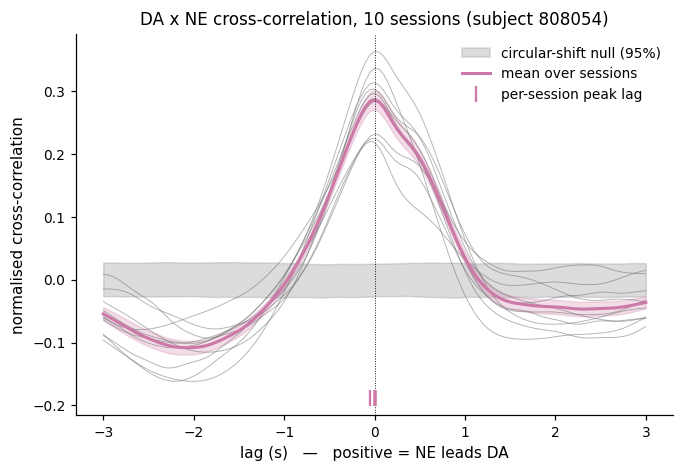

In [44]:
curves = np.vstack([s["xcorr"] for s in sessions])
null_lo = np.mean([s["xcorr_null_lo"] for s in sessions], axis=0)
null_hi = np.mean([s["xcorr_null_hi"] for s in sessions], axis=0)
mean_cc = curves.mean(axis=0)
sem_cc = curves.std(axis=0, ddof=1) / np.sqrt(len(curves))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(lags_ref, null_lo, null_hi, color=PALETTE["not_sig"], alpha=0.35,
                label="circular-shift null (95%)")
for c in curves:
    ax.plot(lags_ref, c, color=PALETTE["neutral"], lw=0.6, alpha=0.5)
ax.plot(lags_ref, mean_cc, color=SHARED_COLOR, lw=2, label="mean over sessions")
ax.fill_between(lags_ref, mean_cc - sem_cc, mean_cc + sem_cc, color=SHARED_COLOR, alpha=0.25)
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.plot(df_xcorr["peak_lag_s"], np.full(len(df_xcorr), ax.get_ylim()[0]), "|",
        color=SHARED_COLOR, ms=10, mew=1.5, label="per-session peak lag")
ax.set_xlabel("lag (s)   —   positive = NE leads DA")
ax.set_ylabel("normalised cross-correlation")
ax.set_title("DA x NE cross-correlation, %d sessions (subject %s)"
             % (len(sessions), ", ".join(subjects)))
ax.legend(loc="upper right")
style_ax(ax)
save_fig(fig, "fip_03_fig2_xcorr_%s" % RUN_TAG, fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3b. Coherence — which timescales carry the relationship

Coherence is the frequency-resolved counterpart of the cross-correlation above: the two are a
Fourier transform pair, so nothing is lost moving between them. At each frequency it asks how
consistently the two signals hold the same phase and amplitude relationship across segments of
the recording, on a 0-to-1 scale that reads like a squared correlation. There is no lag
dimension here; lag is section 3's measurement.

Significance is a cluster-based permutation test. A per-frequency threshold would control
nothing across 513 frequency bins — on genuinely independent signals the pointwise 97.5% null
flags 8 to 18 bins every time. Instead, contiguous runs of frequencies above a cluster-forming
threshold are scored by their total area above it, and compared against the largest cluster the
circular-shift null produces anywhere in the spectrum. Two consequences worth knowing: narrow
instrumental spikes (the FIP system time-multiplexes its channels, so harmonics of the cycle
rate appear) are rejected for lack of width, and the circular-shift null independently handles
sustained tones, which stay coherent with their own shifted copies and so raise the null at
exactly their own frequency.

The trade is that cluster tests are biased toward broad effects. A genuinely narrowband
coupling would be rejected here for being narrow, so absence of a narrow cluster is not
evidence that none exists.

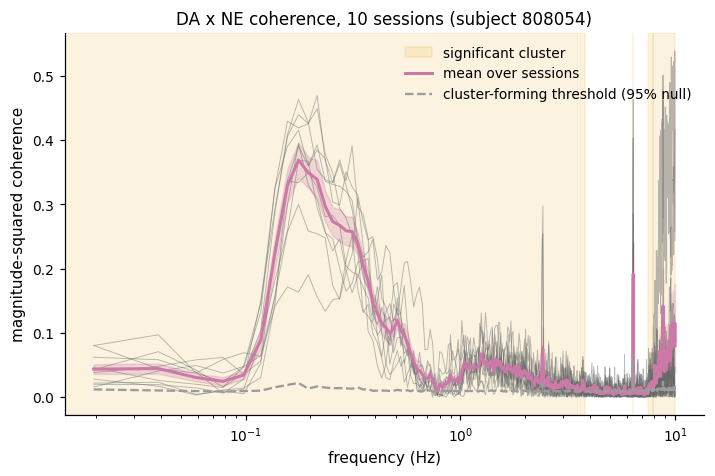

 lo_Hz  hi_Hz  n_bins  peak_coh  peak_Hz  mass     p  timescale_s
 0.000  3.516     181     0.369    0.176 7.926 0.005        5.689
 3.594  3.809      12     0.027    3.711 0.067 0.045        0.269
 6.367  6.387       2     0.192    6.387 0.226 0.030        0.157
 7.500  7.891      21     0.025    7.812 0.159 0.040        0.128
 7.930 10.000     107     0.142    8.789 5.570 0.005        0.114

critical cluster mass 0.050 from 200 shifts; p floor 0.0050
Lag is section 3's measurement; this cell reports frequency only.


In [45]:
COH_NPERSEG = 1024   # 51.2 s segments -> 0.02 Hz resolution, ~175 segments per session
N_SHIFT_COH = 200
CLUSTER_ALPHA = 0.05


def contiguous_runs(mask):
    """[(start, end)] index pairs for each contiguous True run in a boolean mask."""
    out, i, n = [], 0, len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j + 1 < n and mask[j + 1]:
                j += 1
            out.append((i, j))
            i = j + 1
        else:
            i += 1
    return out


coh_all, null_all = [], []
for s in sessions:
    f_coh, cxy = signal.coherence(s["da"], s["ne"], fs=FS, nperseg=COH_NPERSEG)
    coh_all.append(cxy)
    n_s = len(s["ne"])
    nl = np.empty((N_SHIFT_COH, len(f_coh)))
    for i in range(N_SHIFT_COH):
        sh = int(rng.integers(FS, n_s - FS))
        nl[i] = signal.coherence(s["da"], np.roll(s["ne"], sh), fs=FS, nperseg=COH_NPERSEG)[1]
    null_all.append(nl)

coh_all = np.vstack(coh_all)
mean_coh = coh_all.mean(axis=0)
sem_coh = coh_all.std(axis=0, ddof=1) / np.sqrt(len(coh_all))
null_mean = np.stack(null_all).mean(axis=0)        # (N_SHIFT_COH, n_freq): null for the mean

# Cluster-forming threshold, then the null distribution of the largest cluster mass.
thr = np.percentile(null_mean, 95, axis=0)
null_max = np.empty(N_SHIFT_COH)
for i, nl in enumerate(null_mean):
    masses = [float(np.sum(nl[a:b + 1] - thr[a:b + 1])) for a, b in contiguous_runs(nl > thr)]
    null_max[i] = max(masses) if masses else 0.0
crit = float(np.percentile(null_max, 100 * (1 - CLUSTER_ALPHA)))

found = []
for a, b in contiguous_runs(mean_coh > thr):
    mass = float(np.sum(mean_coh[a:b + 1] - thr[a:b + 1]))
    if mass > crit:
        found.append({"lo_Hz": f_coh[a], "hi_Hz": f_coh[b], "n_bins": b - a + 1,
                      "peak_coh": float(mean_coh[a:b + 1].max()),
                      "peak_Hz": float(f_coh[a:b + 1][int(np.argmax(mean_coh[a:b + 1]))]),
                      "mass": mass,
                      "p": (1 + int(np.sum(null_max >= mass))) / (1 + N_SHIFT_COH)})

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for k, c in enumerate(found):          # shade each cluster separately, never min-to-max: the
    ax.axvspan(c["lo_Hz"], c["hi_Hz"], color=PALETTE["sig"], alpha=0.12, zorder=0,
               label="significant cluster" if k == 0 else None)
for c in coh_all:
    ax.semilogx(f_coh[1:], c[1:], color=PALETTE["neutral"], lw=0.6, alpha=0.45)
ax.semilogx(f_coh[1:], mean_coh[1:], color=SHARED_COLOR, lw=2, label="mean over sessions")
ax.fill_between(f_coh[1:], (mean_coh - sem_coh)[1:], (mean_coh + sem_coh)[1:],
                color=SHARED_COLOR, alpha=0.25)
ax.semilogx(f_coh[1:], thr[1:], color=PALETTE["not_sig"], lw=1.5, ls="--",
            label="cluster-forming threshold (95% null)")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("magnitude-squared coherence")
ax.set_title("DA x NE coherence, %d sessions (subject %s)"
             % (len(sessions), ", ".join(subjects)))
ax.legend(loc="upper right")
style_ax(ax)
save_fig(fig, "fip_03_fig3b_coherence_%s" % RUN_TAG, fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

if found:
    df_clust = pd.DataFrame(found)
    df_clust["timescale_s"] = 1.0 / df_clust["peak_Hz"]
    print(df_clust.to_string(index=False, float_format=lambda v: "%.3f" % v))
else:
    print("No cluster survives (critical mass %.3f)." % crit)
print("\ncritical cluster mass %.3f from %d shifts; p floor %.4f"
      % (crit, N_SHIFT_COH, 1.0 / (1 + N_SHIFT_COH)))
print("Lag is section 3's measurement; this cell reports frequency only.")

## 4. Event-locked co-fluctuation

The cross-correlation above is a session-wide average. This section asks whether the two signals
also co-vary event by event: both are aligned to movement onsets, each event gets one DA
amplitude and one NE amplitude, and the two amplitudes are correlated within each session.

Amplitude is the mean over 0 to 1 s after onset minus the mean over the 1 s before it. Movement
onsets fall close together, so alignment runs with `censor=False` — censoring against neighbours
would erase most windows. The correlation across events within a session is one number per
session, and the test across the 10 sessions is what carries the claim; the pooled cloud of
events is shown but not tested.

In [46]:
RESP_WIN = (0.0, 1.0)   # s after onset
BASE_WIN = (-1.0, 0.0)  # s before onset


def event_amps(etr):
    """Per-event response amplitude from a tidy event-triggered response.

    Parameters
    ----------
    etr : pandas.DataFrame
        Output of ``fu.peri_event`` -- columns ``[time, event_number, data]``.

    Returns
    -------
    pandas.Series
        Baseline-subtracted mean response, indexed by ``event_number``.
    """
    piv = etr.pivot_table(index="time", columns="event_number", values="data")
    idx = piv.index.to_numpy(float)
    resp = piv.loc[(idx >= RESP_WIN[0]) & (idx < RESP_WIN[1])].mean()
    base = piv.loc[(idx >= BASE_WIN[0]) & (idx < BASE_WIN[1])].mean()
    return resp - base


for s in sessions:
    etr_da = fu.peri_event(s["t"], s["da"], s["me_onsets"], t_before=1.0, t_after=2.0,
                           fs=FS, censor=False)
    etr_ne = fu.peri_event(s["t"], s["ne"], s["me_onsets"], t_before=1.0, t_after=2.0,
                           fs=FS, censor=False)
    s["etr_da"] = etr_da.groupby("time")["data"].mean()
    s["etr_ne"] = etr_ne.groupby("time")["data"].mean()

    a_da, a_ne = event_amps(etr_da), event_amps(etr_ne)
    ok = a_da.notna() & a_ne.notna()
    a_da, a_ne = a_da[ok].to_numpy(), a_ne[ok].to_numpy()

    s["amp_rho"] = float(stats.spearmanr(a_da, a_ne).statistic)
    null = np.array([stats.spearmanr(a_da, rng.permutation(a_ne)).statistic
                     for _ in range(N_SHIFT)])
    s["amp_null_lo"], s["amp_null_hi"] = np.percentile(null, [2.5, 97.5])
    s["n_events"] = int(len(a_da))

df_amp = pd.DataFrame([{"session": s["session_id"], "n_events": s["n_events"],
                        "rho": s["amp_rho"]} for s in sessions])
w_amp = stats.wilcoxon(df_amp["rho"])
print("per-session Spearman rho(DA amp, NE amp): median %.3f, range %.3f to %.3f"
      % (df_amp["rho"].median(), df_amp["rho"].min(), df_amp["rho"].max()))
print("across %d sessions vs. 0: Wilcoxon W=%.1f, p=%.4f"
      % (len(df_amp), w_amp.statistic, w_amp.pvalue))
df_amp

per-session Spearman rho(DA amp, NE amp): median 0.284, range 0.142 to 0.438
across 10 sessions vs. 0: Wilcoxon W=0.0, p=0.0020


,session,n_events,rho
0,808054_2025-09-02,927,0.141788
1,808054_2025-09-03,1098,0.248853
2,808054_2025-09-04,1237,0.157188
3,808054_2025-09-05,796,0.217612
4,808054_2025-09-08,1138,0.156645
5,808054_2025-09-09,1128,0.319130
6,808054_2025-09-10,1069,0.323574
7,808054_2025-09-11,1155,0.346777
8,808054_2025-09-12,1206,0.413173
9,808054_2025-09-15,1203,0.438125


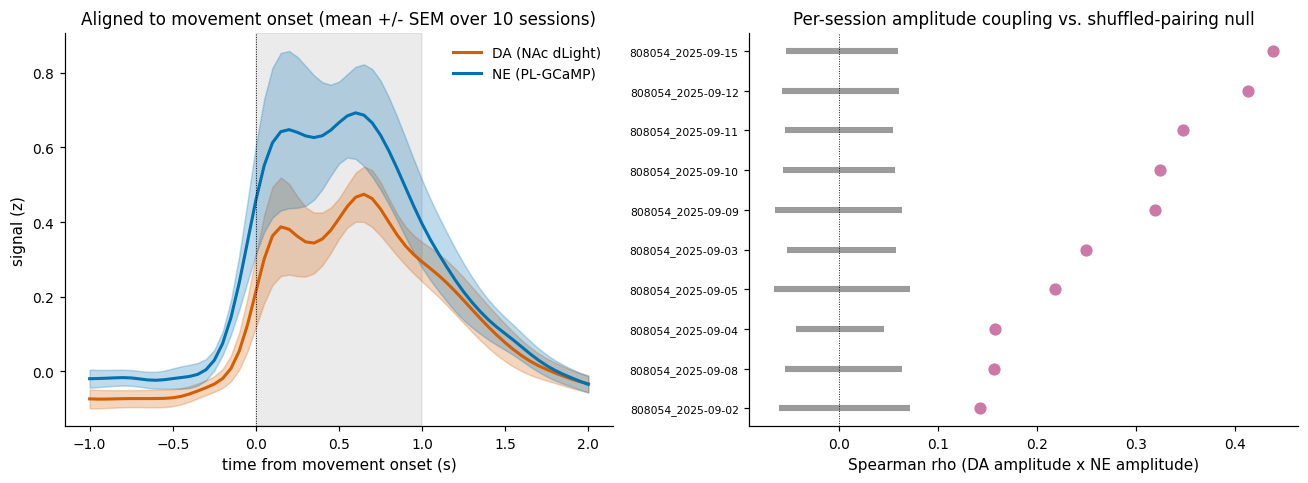

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
t_grid = sessions[0]["etr_da"].index.to_numpy(float)
for key, color, label in [("etr_da", DA_COLOR, "DA (NAc dLight)"),
                          ("etr_ne", NE_COLOR, "NE (PL-GCaMP)")]:
    mat = np.vstack([s[key].reindex(t_grid).to_numpy() for s in sessions])
    m = np.nanmean(mat, axis=0)
    e = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(len(mat))
    ax.plot(t_grid, m, color=color, lw=2, label=label)
    ax.fill_between(t_grid, m - e, m + e, color=color, alpha=0.25)
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.axvspan(RESP_WIN[0], RESP_WIN[1], color=PALETTE["not_sig"], alpha=0.2, zorder=0)
ax.set_xlabel("time from movement onset (s)")
ax.set_ylabel("signal (z)")
ax.set_title("Aligned to movement onset (mean +/- SEM over %d sessions)" % len(sessions))
ax.legend()
style_ax(ax)

ax = axes[1]
order = np.argsort([s["amp_rho"] for s in sessions])
for row, j in enumerate(order):
    s = sessions[j]
    ax.plot([s["amp_null_lo"], s["amp_null_hi"]], [row, row], color=PALETTE["not_sig"], lw=4,
            solid_capstyle="butt", zorder=1)
    ax.plot(s["amp_rho"], row, "o", color=SHARED_COLOR, ms=7, zorder=2)
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_yticks(range(len(sessions)))
ax.set_yticklabels([sessions[j]["session_id"] for j in order], fontsize=7)
ax.set_xlabel("Spearman rho (DA amplitude x NE amplitude)")
ax.set_title("Per-session amplitude coupling vs. shuffled-pairing null")
style_ax(ax)

fig.tight_layout()
save_fig(fig, "fip_03_fig3_event_coupling_%s" % RUN_TAG, fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### What the lag in §3 and §4 can support

dLight and GCaMP have different rise and decay kinetics, so a peak in the cross-correlation
function sits where it does partly because of the indicators and partly because of the
transmitters, and those two contributions cannot be separated from these data. A peak lag is
read here as a description of the measured signals, and a directional claim about DA driving NE
or the reverse does not follow from it.

Granger causality and transfer entropy are left out for the same reason: both would return a
direction, and with two differently-filtered observations of two latent processes that direction
would be a statement about sensor kinetics wearing causal language.

## 5. Encoding model against motion energy

Each signal enters as time-lagged copies spanning −2 to +5 s, where positive lag means the FIP
signal leads behavior. The 141 lags are projected onto `N_BASIS` raised-cosine bumps placed on a
log-warped lag axis, so resolution is finest near zero lag and coarsest at the edges; that keeps
the design at 8 columns per signal instead of 141.

Cross-validation uses contiguous blocks. Both the predictors and the target are autocorrelated
over seconds, so randomly held-out samples would sit beside their own training neighbours and the
score would measure interpolation. Each test block is additionally separated from its training
data by an `EMBARGO_S` gap on both sides, because the lagged design reaches across the block
boundary. Held-out scores are computed against the **training-fold mean**, which makes a negative
score possible and meaningful.

One ridge penalty is selected per session from the joint design and reused for the DA-only and
NE-only fits, so §6's comparison between nested models is not confounded by different
regularization.

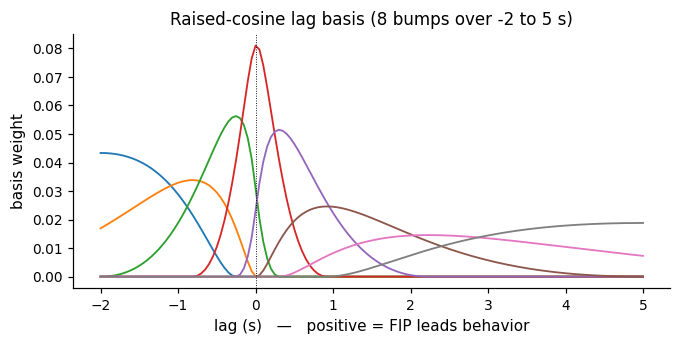

In [48]:
LAG_SAMPLES = np.arange(int(round(LAG_WINDOW[0] * FS)), int(round(LAG_WINDOW[1] * FS)) + 1)
LAG_S = LAG_SAMPLES / float(FS)

# Log-warped lag axis: bumps are narrow near zero lag and wide at the edges.
WARP_C = 0.25
_u = np.sign(LAG_S) * np.log1p(np.abs(LAG_S) / WARP_C)
_centers = np.linspace(_u.min(), _u.max(), N_BASIS)
_dc = _centers[1] - _centers[0]

B = np.zeros((len(LAG_S), N_BASIS))
for j, ctr in enumerate(_centers):
    d = (_u - ctr) * np.pi / (2.0 * _dc)
    m = np.abs(d) < np.pi
    B[m, j] = 0.5 * (1.0 + np.cos(d[m]))
B /= B.sum(axis=0, keepdims=True)  # each column is a weighted average over lags

fig, ax = plt.subplots(figsize=(7, 3))
for j in range(N_BASIS):
    ax.plot(LAG_S, B[:, j], lw=1.2)
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("lag (s)   —   positive = FIP leads behavior")
ax.set_ylabel("basis weight")
ax.set_title("Raised-cosine lag basis (%d bumps over %.0f to %.0f s)"
             % (N_BASIS, LAG_WINDOW[0], LAG_WINDOW[1]))
style_ax(ax)
plt.show()

In [49]:
TRIM_HEAD = int(max(LAG_SAMPLES.max(), 0))
TRIM_TAIL = int(max(-LAG_SAMPLES.min(), 0))


def lagged_design(x, basis=B, lag_samples=LAG_SAMPLES):
    """Project time-lagged copies of a signal onto a lag basis.

    ``X[t, j] = sum_k basis[k, j] * x[t - lag_samples[k]]``, so a positive lag column reads the
    signal's past and a positive weight on it means the signal leads the target.

    Parameters
    ----------
    x : array_like
        Signal on the common grid.
    basis : numpy.ndarray
        ``(n_lags, n_basis)`` lag basis.
    lag_samples : numpy.ndarray
        Lags in samples, matching ``basis`` rows.

    Returns
    -------
    numpy.ndarray
        ``(n_samples, n_basis)`` design block; edge rows are zero-filled and trimmed by callers.
    """
    x = np.asarray(x, float)
    n = len(x)
    X = np.zeros((n, basis.shape[1]))
    for k, lag in enumerate(lag_samples):
        w = basis[k]
        nz = np.nonzero(w)[0]
        if not len(nz):
            continue
        xs = np.zeros(n)
        if lag >= 0:
            xs[lag:] = x[:n - lag] if lag else x
        else:
            xs[:n + lag] = x[-lag:]
        X[:, nz] += xs[:, None] * w[nz]
    return X


def _poisson_dev(y, mu):
    """Poisson deviance between counts ``y`` and rate ``mu`` (both 1-D)."""
    mu = np.clip(np.asarray(mu, float), 1e-9, None)
    y = np.asarray(y, float)
    term = np.where(y > 0, y * np.log(np.where(y > 0, y, 1.0) / mu), 0.0)
    return 2.0 * np.sum(term - (y - mu))


def _fit_predict(X_tr, y_tr, X_te, alpha):
    """Fit one model on standardized predictors and predict the held-out block."""
    mu, sd = X_tr.mean(axis=0), X_tr.std(axis=0)
    sd[sd == 0] = 1.0
    if TARGET == "continuous":
        mdl = Ridge(alpha=alpha)
    else:
        mdl = PoissonRegressor(alpha=alpha, max_iter=500)
    mdl.fit((X_tr - mu) / sd, y_tr)
    return mdl, mdl.predict((X_te - mu) / sd), mu, sd


def _score(y_te, pred, y_tr):
    """Held-out score against the training-fold mean as the null model."""
    if TARGET == "continuous":
        ss_res = np.sum((y_te - pred) ** 2)
        ss_tot = np.sum((y_te - y_tr.mean()) ** 2)
        return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    base = np.full(len(y_te), max(y_tr.mean(), 1e-9))
    dev_null = _poisson_dev(y_te, base)
    return 1.0 - _poisson_dev(y_te, pred) / dev_null if dev_null > 0 else np.nan


def block_cv_score(X, y, alpha):
    """Mean held-out score across contiguous blocks with an embargo.

    Parameters
    ----------
    X : numpy.ndarray
        ``(n_samples, n_features)`` design.
    y : numpy.ndarray
        Target on the same grid.
    alpha : float
        Regularization strength, fixed across nested models.

    Returns
    -------
    float
        Mean of the per-block held-out scores.
    """
    n = len(y)
    edges = np.linspace(0, n, N_BLOCKS + 1).astype(int)
    emb = int(round(EMBARGO_S * FS))
    out = []
    for b in range(N_BLOCKS):
        te = np.zeros(n, bool)
        te[edges[b]:edges[b + 1]] = True
        excl = np.zeros(n, bool)
        excl[max(0, edges[b] - emb):min(n, edges[b + 1] + emb)] = True
        tr = ~excl
        if tr.sum() < 100 or te.sum() < 10:
            continue
        _, pred, _, _ = _fit_predict(X[tr], y[tr], X[te], alpha)
        out.append(_score(y[te], pred, y[tr]))
    return float(np.nanmean(out)) if out else np.nan


def select_alpha(X, y):
    """Pick a ridge penalty on one contiguous inner split, embargoed from the validation part."""
    n = len(y)
    cut = int(0.8 * n)
    emb = int(round(EMBARGO_S * FS))
    tr = slice(0, max(cut - emb, 10))
    va = slice(cut, n)
    best, best_a = -np.inf, ALPHAS[0]
    for a in ALPHAS:
        _, pred, _, _ = _fit_predict(X[tr], y[tr], X[va], a)
        sc = _score(y[va], pred, y[tr])
        if np.isfinite(sc) and sc > best:
            best, best_a = sc, a
    return best_a

In [50]:
for s in sessions:
    X_da = lagged_design(s["da"])
    X_ne = lagged_design(s["ne"])
    keep = slice(TRIM_HEAD, len(s["y"]) - TRIM_TAIL)
    s["X_da"], s["X_ne"] = X_da[keep], X_ne[keep]
    s["X_joint"] = np.hstack([s["X_da"], s["X_ne"]])
    s["y_fit"] = s["y"][keep]

    s["alpha"] = select_alpha(s["X_joint"], s["y_fit"])
    s["score_joint"] = block_cv_score(s["X_joint"], s["y_fit"], s["alpha"])

    # Kernels: one fit on the whole session, weights mapped back through the basis.
    mdl, _, _, _ = _fit_predict(s["X_joint"], s["y_fit"], s["X_joint"][:1], s["alpha"])
    w = mdl.coef_.ravel()
    s["kernel_da"] = B.dot(w[:N_BASIS])
    s["kernel_ne"] = B.dot(w[N_BASIS:])

    # Does the joint model beat chance at all? Shift both signals together against the target,
    # which keeps the DA-NE relationship intact and breaks only the link to behavior.
    n_fit = len(s["y_fit"])
    null_scores = np.empty(N_PERM)
    for i in range(N_PERM):
        sh = int(rng.integers(FS, n_fit - FS))
        null_scores[i] = block_cv_score(s["X_joint"], np.roll(s["y_fit"], sh), s["alpha"])
    s["score_p"] = (1 + int(np.sum(null_scores >= s["score_joint"]))) / (1 + N_PERM)

df_joint = pd.DataFrame([{"session": s["session_id"], "alpha": s["alpha"],
                          "score_joint": s["score_joint"], "p_shift": s["score_p"]}
                         for s in sessions])
print("joint model %s: median %.4f, range %.4f to %.4f"
      % (SCORE_LABEL, df_joint["score_joint"].median(),
         df_joint["score_joint"].min(), df_joint["score_joint"].max()))
print("sessions above their circular-shift null at p<0.05: %d / %d"
      % (int((df_joint["p_shift"] < 0.05).sum()), len(df_joint)))
df_joint

joint model cross-validated R$^2$: median 0.3197, range 0.0922 to 0.4393
sessions above their circular-shift null at p<0.05: 10 / 10


,session,alpha,score_joint,p_shift
0,808054_2025-09-02,10.0,0.439306,0.019608
1,808054_2025-09-03,10.0,0.235444,0.019608
2,808054_2025-09-04,100.0,0.319009,0.019608
3,808054_2025-09-05,100.0,0.092158,0.019608
4,808054_2025-09-08,100.0,0.320319,0.019608
5,808054_2025-09-09,0.1,0.203633,0.019608
6,808054_2025-09-10,1.0,0.337963,0.019608
7,808054_2025-09-11,0.1,0.315947,0.019608
8,808054_2025-09-12,0.1,0.342322,0.019608
9,808054_2025-09-15,100.0,0.368187,0.019608


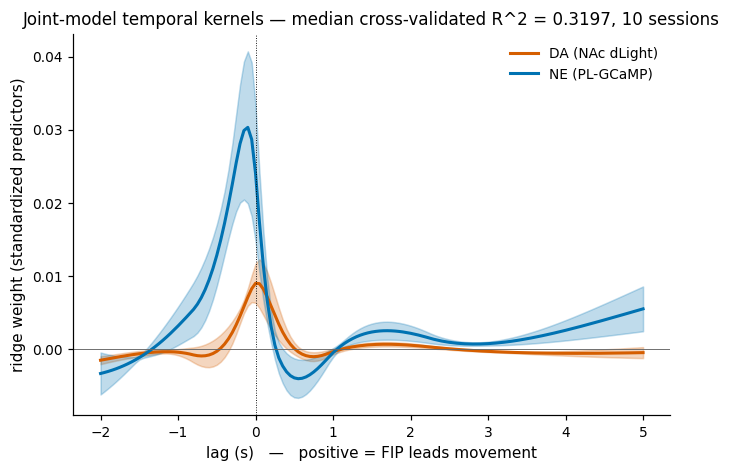

In [51]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for key, color, label in [("kernel_da", DA_COLOR, "DA (NAc dLight)"),
                          ("kernel_ne", NE_COLOR, "NE (PL-GCaMP)")]:
    mat = np.vstack([s[key] for s in sessions])
    m = mat.mean(axis=0)
    e = mat.std(axis=0, ddof=1) / np.sqrt(len(mat))
    ax.plot(LAG_S, m, color=color, lw=2, label=label)
    ax.fill_between(LAG_S, m - e, m + e, color=color, alpha=0.25)
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.axhline(0, color=PALETTE["neutral"], lw=0.6)
ax.set_xlabel("lag (s)   —   positive = FIP leads movement")
ax.set_ylabel("ridge weight (standardized predictors)")
ax.set_title("Joint-model temporal kernels — median %s = %.4f, %d sessions"
             % (SCORE_LABEL.replace("$", ""), df_joint["score_joint"].median(), len(sessions)))
ax.legend()
style_ax(ax)
save_fig(fig, "fip_03_fig4_kernels_%s" % RUN_TAG, fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Commonality analysis

With held-out scores for the DA-only, NE-only and joint models, the variance each signal explains
splits three ways:

- **DA-unique** = joint − NE-only: what DA adds once NE is already in the model.
- **NE-unique** = joint − DA-only: what NE adds once DA is already in the model.
- **Shared** = DA-only + NE-only − joint: variance either signal could have supplied.

On cross-validated scores these components are not guaranteed to be non-negative. A negative
shared component means the two signals together predict better than the sum of their separate
predictions, which happens under suppression and also under cross-validation noise. They are
plotted as computed rather than clipped at zero.

The confidence intervals resample the 10 sessions with replacement. They describe sampling
variability across sessions within one animal.

In [52]:
def commonality(score_da, score_ne, score_joint):
    """Split explained variance into DA-unique, NE-unique and shared parts.

    Parameters
    ----------
    score_da, score_ne, score_joint : float
        Held-out scores for the DA-only, NE-only and joint models.

    Returns
    -------
    dict
        ``{'DA-unique', 'NE-unique', 'shared'}``.
    """
    return {"DA-unique": score_joint - score_ne,
            "NE-unique": score_joint - score_da,
            "shared": score_da + score_ne - score_joint}


rows = []
for s in sessions:
    s["score_da"] = block_cv_score(s["X_da"], s["y_fit"], s["alpha"])
    s["score_ne"] = block_cv_score(s["X_ne"], s["y_fit"], s["alpha"])
    parts = commonality(s["score_da"], s["score_ne"], s["score_joint"])
    s.update(parts)
    rows.append(dict(session=s["session_id"], subject=s["subject_id"],
                     score_da=s["score_da"], score_ne=s["score_ne"],
                     score_joint=s["score_joint"], **parts))

df_common = pd.DataFrame(rows)
df_common

,session,subject,score_da,score_ne,score_joint,DA-unique,NE-unique,shared
0,808054_2025-09-02,808054,0.100614,0.401265,0.439306,0.038042,0.338693,0.062572
1,808054_2025-09-03,808054,0.056524,0.225834,0.235444,0.009611,0.178920,0.046913
2,808054_2025-09-04,808054,0.084399,0.311102,0.319009,0.007908,0.234610,0.076492
3,808054_2025-09-05,808054,0.025989,0.088815,0.092158,0.003343,0.066168,0.022647
4,808054_2025-09-08,808054,0.094563,0.308319,0.320319,0.012000,0.225757,0.082562
5,808054_2025-09-09,808054,0.031995,0.200357,0.203633,0.003276,0.171638,0.028719
6,808054_2025-09-10,808054,0.065777,0.332115,0.337963,0.005847,0.272186,0.059929
7,808054_2025-09-11,808054,0.087911,0.301201,0.315947,0.014746,0.228036,0.073165
8,808054_2025-09-12,808054,0.065373,0.337142,0.342322,0.005180,0.276949,0.060193
9,808054_2025-09-15,808054,0.087519,0.358622,0.368187,0.009565,0.280668,0.077954


In [53]:
COMPONENTS = ["DA-unique", "NE-unique", "shared"]
COMP_COLORS = {"DA-unique": DA_COLOR, "NE-unique": NE_COLOR, "shared": SHARED_COLOR}

boot = {c: np.empty(N_BOOT) for c in COMPONENTS}
idx_all = np.arange(len(df_common))
for i in range(N_BOOT):
    take = rng.choice(idx_all, size=len(idx_all), replace=True)
    for c in COMPONENTS:
        boot[c][i] = df_common[c].to_numpy()[take].mean()

summary = pd.DataFrame([{
    "component": c,
    "mean": df_common[c].mean(),
    "ci_lo": np.percentile(boot[c], 2.5),
    "ci_hi": np.percentile(boot[c], 97.5),
    "p_boot": (1 + int(np.sum(boot[c] <= 0))) / (1 + N_BOOT),
} for c in COMPONENTS])
print("pooled over %d sessions, %d bootstrap resamples" % (len(df_common), N_BOOT))
summary

pooled over 10 sessions, 10000 bootstrap resamples


,component,mean,ci_lo,ci_hi,p_boot
0,DA-unique,0.010952,0.006276,0.017820,0.0001
1,NE-unique,0.227363,0.179760,0.268775,0.0001
2,shared,0.059115,0.046473,0.070440,0.0001


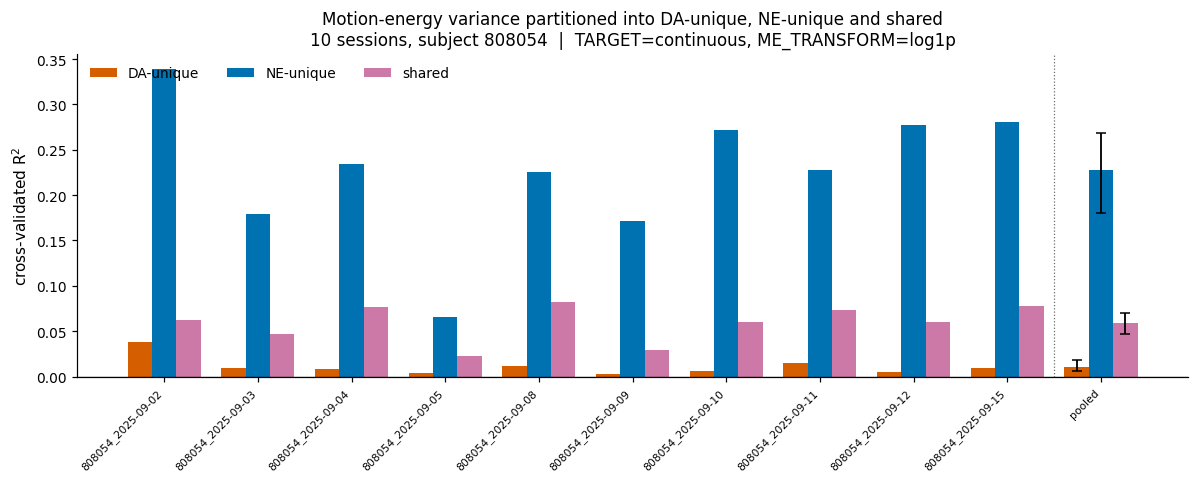

In [54]:
fig, ax = plt.subplots(figsize=(11, 4.5))
n_sess = len(df_common)
width = 0.26
x = np.arange(n_sess + 1)

for k, c in enumerate(COMPONENTS):
    vals = np.append(df_common[c].to_numpy(), summary.loc[k, "mean"])
    err = np.full((2, len(vals)), np.nan)
    err[:, -1] = [summary.loc[k, "mean"] - summary.loc[k, "ci_lo"],
                  summary.loc[k, "ci_hi"] - summary.loc[k, "mean"]]
    ax.bar(x + (k - 1) * width, vals, width, color=COMP_COLORS[c], label=c,
           yerr=err, error_kw={"lw": 1.2, "capsize": 3, "ecolor": "k"})

ax.axhline(0, color="k", lw=0.8)
ax.axvline(n_sess - 0.5, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_xticks(x)
ax.set_xticklabels(list(df_common["session"]) + ["pooled"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel(SCORE_LABEL)
ax.set_title("Motion-energy variance partitioned into DA-unique, NE-unique and shared\n"
             "%d sessions, subject %s  |  TARGET=%s, ME_TRANSFORM=%s"
             % (n_sess, ", ".join(subjects), TARGET, ME_TRANSFORM))
ax.legend(ncol=3, loc="upper left")
style_ax(ax)
fig.tight_layout()
save_fig(fig, "fip_03_fig5_commonality_%s" % RUN_TAG, fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 7. What the shared component means here

Read §6 through §3 and §4.

**When the shared component is large.** §3 and §4 establish how tightly the two signals track
each other. Where the cross-correlation peaks near zero lag and event amplitudes co-vary within
sessions, a large shared component says the model cannot assign that variance to either signal,
because either one carries it. That is a statement about what these two measurements can
distinguish, and it is consistent with a common drive reaching both, with one transmitter
driving the other, and with a third variable — arousal, or movement itself — modulating both.
The partition does not separate those.

**When a unique component is large.** DA-unique variance is variance NE cannot supply at any lag
in the −2 to +5 s window. §2's spectra qualify that: if the two channels have different median
power frequencies, the faster channel can express structure the slower one cannot represent, and
part of its unique component follows from sensor kinetics rather than from transmitter dynamics.
The size of that gap in §2 bounds how much of §6's asymmetry can be read as biology.

**What the lag structure in §5 does not license.** Weight at positive lag means the signal's past
predicts current movement. §4's caveat applies unchanged: indicator kinetics shift where
predictive weight falls, so a kernel peaking earlier for one signal is not evidence that its
transmitter acts earlier.

**Scope.** Ten sessions from one animal (808054). The bootstrap intervals in §6 describe
variability across sessions within that animal; they are not intervals on a population mean, and
nothing here estimates between-animal variability. "NE" is PL-GCaMP throughout.

## 8. Extensions

- **Animal-level inference.** Motion energy exists for 10 sessions from one animal. Swapping the
  behavioral target to lick or choice events from `df_trials` reaches ~172 curated sessions across
  20 subjects, which supports a test with animal as the unit. That means `TARGET = "events"` with
  a different event source in §2, and §6's bootstrap resampling animals rather than sessions.
- **More motion energy.** Behavior-video assets exist for 20 subjects; running `aind-motion-energy`
  (capsule 5110154) over more of them widens the current path instead of changing the target.
- **Both switches.** This run used `TARGET` / `ME_TRANSFORM` as printed in §1. Comparing the §6
  partition across the four combinations shows how much of the split depends on target scaling.

Mirror these into `code/fip_todo.md`.

**Figure style note**: this notebook uses `plotstyle.py` (`apply_style` / `PALETTE` / `style_ax` /
`save_fig`), where `fip_00`–`fip_02` use bare matplotlib with `EXAMPLE_SPECS` hexes. Figures are
written to `/root/capsule/scratch/figures/fip`, which a reproducible run does not preserve —
copy anything headed for a paper figure to `/results`.